In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from fmri_mapping.embedding.evaluation import compute_rsa, accuracy_cosine_similarity
from fmri_mapping.embedding.ops import split_repetitions
from fmri_mapping.io.nsd import get_resource
from tqdm.notebook import trange
import torch

def get_common_nsd_id_stimuli(min_reps: int = 3):
    df = get_resource("stimulus").query(
        "shared and exists and (repetition == @min_reps - 1)"
    )
    df_count_subjects = df.groupby("nsd_id").subject.count().reset_index()
    df_count_subjects = df_count_subjects[
        df_count_subjects.subject == 8
    ]  # All subjects

    return list(df_count_subjects.nsd_id.unique())


test_stimuli = get_common_nsd_id_stimuli()


Raw fMRI

In [ ]:
def raw_fmri_avg(subject: int, template_file: str):
    df_reps = split_repetitions(subject=subject)
    df_reps = df_reps.query("nsd_id in @test_stimuli").reset_index(drop=True)


    X = np.load(template_file.format(subject=subject))

    X1 = X[df_reps.subject_index_1]
    X2 = X[df_reps.subject_index_2]
    X3 = X[df_reps.subject_index_3]
    X_avg = (X1 + X2 + X3) / 3

    return X_avg

template_file = "../scripts/steps/subject-{subject:02d}_betas_prec.npy"

raw_fmri = []

for subject in trange(1, 9):
    raw_fmri.append(torch.tensor(raw_fmri_avg(subject, template_file)))

In [5]:
similarities_raw_fmri = np.zeros((len(raw_fmri), len(raw_fmri)))
fmri_results = []
for i in trange(len(raw_fmri)):
    for j in range(len(raw_fmri)):
        sim = compute_rsa(raw_fmri[i], raw_fmri[j])
        similarities_raw_fmri[i, j] = sim

  0%|          | 0/8 [00:00<?, ?it/s]

<Axes: >

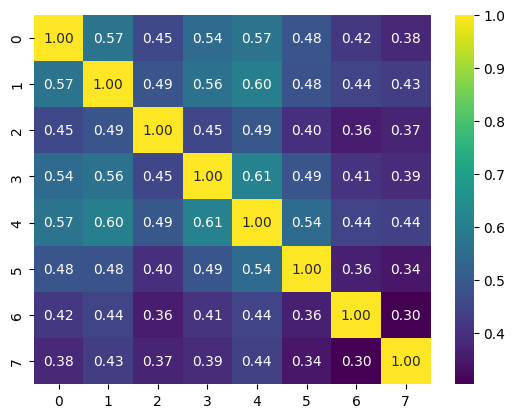

In [11]:
np.save("similarities_raw_fmri.npy", similarities_raw_fmri)
sns.heatmap(similarities_raw_fmri, annot=True, fmt=".2f", cmap="viridis")

Ours (full encoder)

  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/8 [00:00<?, ?it/s]

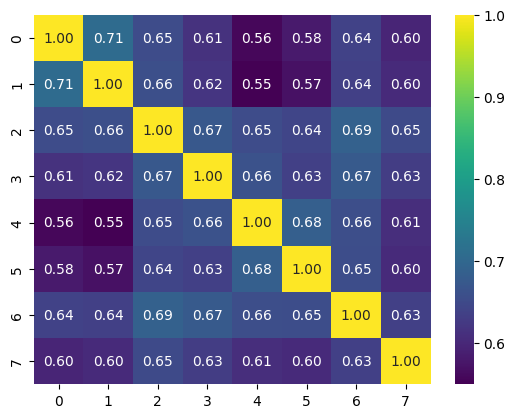

In [12]:
template_file = "../scripts/mlp_embeddings_standarized/avg_ws_mlp_v1_128_768_sub-{subject:02d}.pt"

encoder_subject = []
encoder_similarities = np.zeros((8, 8))

for subject in trange(1, 9):
    pck = torch.load(template_file.format(subject=subject))
    Z_test = pck["Z_test"]
    Z_test = Z_test[:515, :] # Already sorted
    encoder_subject.append(Z_test)

for i in trange(len(encoder_subject)):
    for j in range(len(encoder_subject)):
        sim = compute_rsa(encoder_subject[i], encoder_subject[j])
        encoder_similarities[i, j] = sim

sns.heatmap(encoder_similarities, annot=True, fmt=".2f", cmap="viridis")
np.save("similarities_encoder_fmri.npy", encoder_similarities)


Model based

  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/8 [00:00<?, ?it/s]

<Axes: >

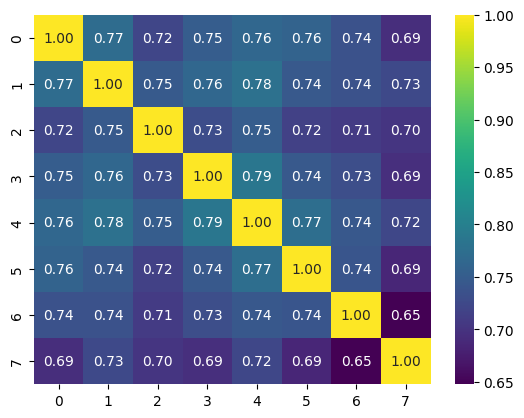

In [63]:
template_file = "vit_large_patch16_224.augreg_in21k_pool-cls_subject-{subject:02d}_layer-23_features.npy"

model_embeddings = []
for subject in trange(1, 9):
    features = raw_fmri_avg(subject=subject, template_file=template_file)
    model_embeddings.append(torch.tensor(features))


model_similarities = np.zeros((8, 8))
for i in trange(len(encoder_subject)):
    for j in range(len(encoder_subject)):
        sim = compute_rsa(model_embeddings[i], model_embeddings[j])
        model_similarities[i, j] = sim


np.save("similarities_encoder_model.npy", model_similarities)
sns.heatmap(model_similarities, annot=True, fmt=".2f", cmap="viridis")

In [80]:
translations_models = []
# Move to cuda the model_embeddings
model_embeddings = [embedding.to("cuda") for embedding in model_embeddings]
for subject_x in trange(1, 9):
    for subject_y in range(1, 9):
        acc, cosine, rank = accuracy_cosine_similarity(
            model_embeddings[subject_x - 1],
            model_embeddings[subject_y - 1]
            )
        rsa = compute_rsa(model_embeddings[subject_x - 1], model_embeddings[subject_y - 1])
        translations_models.append({
            "subject_x": subject_x,
            "subject_y": subject_y,
            "rank": rank,
            "accuracy": acc,
            "cosine_similarity": cosine,
            "rsa": rsa,
            "model": "vit_large_patch16_224.augreg_in21k_pool-cls",
        })
df_translations_models = pd.DataFrame(translations_models)
df_translations_models

  0%|          | 0/8 [00:00<?, ?it/s]

,subject_x,subject_y,rank,accuracy,cosine_similarity,rsa,model
0,1,1,1.000000,1.000000,1.000000,1.000000,vit_large_patch16_224.augreg_in21k_pool-cls
1,1,2,2.966990,0.580583,0.869184,0.771024,vit_large_patch16_224.augreg_in21k_pool-cls
2,1,3,4.662136,0.522330,0.862131,0.721546,vit_large_patch16_224.augreg_in21k_pool-cls
3,1,4,3.866019,0.522330,0.860088,0.750219,vit_large_patch16_224.augreg_in21k_pool-cls
4,1,5,3.596117,0.572816,0.867474,0.763800,vit_large_patch16_224.augreg_in21k_pool-cls
...,...,...,...,...,...,...,...
59,8,4,8.559223,0.349515,0.855795,0.694635,vit_large_patch16_224.augreg_in21k_pool-cls
60,8,5,8.438835,0.411651,0.858759,0.722732,vit_large_patch16_224.augreg_in21k_pool-cls
61,8,6,9.015534,0.363107,0.850922,0.685617,vit_large_patch16_224.augreg_in21k_pool-cls
62,8,7,11.221359,0.314563,0.860012,0.647628,vit_large_patch16_224.augreg_in21k_pool-cls


In [6]:
from pathlib import Path
from tqdm.notebook import tqdm

folder = Path("features_linear")

files = list(folder.glob("*.npy"))
files = [file for file in files if "subject-01" in file.name]
templates = [file.name.replace("subject-01", r"subject-{subject:02d}") for file in files]
templates


results = []
for template_file in tqdm(templates):
    model_embeddings = []
    for subject in range(1, 9):
        features = raw_fmri_avg(subject=subject, template_file=folder.name + "/" +  template_file)
        model_embeddings.append(torch.tensor(features))

    for subject_x in range(1, 9):
        for subject_y in range(1, 9):
            acc, cosine, rank = accuracy_cosine_similarity(
                model_embeddings[subject_x - 1],
                model_embeddings[subject_y - 1]
                )
            rsa = compute_rsa(model_embeddings[subject_x - 1], model_embeddings[subject_y - 1])
            results.append({
                "subject_x": subject_x,
                "subject_y": subject_y,
                "rank": rank,
                "accuracy": acc,
                "cosine_similarity": cosine,
                "rsa": rsa,
                "model": template_file,
            })


df_results = pd.DataFrame(results)
df_results.to_parquet("results_features_linear.parquet")
df_results







  0%|          | 0/24 [00:00<?, ?it/s]

,subject_x,subject_y,rank,accuracy,cosine_similarity,rsa,model
0,1,1,1.000000,1.000000,1.000000,1.000000,vit_large_patch16_224.mae_pool-cls_subject-{su...
1,1,2,3.264078,0.629126,0.999835,0.758245,vit_large_patch16_224.mae_pool-cls_subject-{su...
2,1,3,6.965048,0.508738,0.999820,0.687996,vit_large_patch16_224.mae_pool-cls_subject-{su...
3,1,4,5.332039,0.520388,0.999822,0.724318,vit_large_patch16_224.mae_pool-cls_subject-{su...
4,1,5,3.714563,0.566990,0.999822,0.734079,vit_large_patch16_224.mae_pool-cls_subject-{su...
...,...,...,...,...,...,...,...
1531,8,4,10.813592,0.306796,0.852581,0.735555,nsd_language_embeddings_all-mini_subject-{subj...
1532,8,5,10.355340,0.297087,0.852025,0.751831,nsd_language_embeddings_all-mini_subject-{subj...
1533,8,6,9.805825,0.289320,0.842780,0.740045,nsd_language_embeddings_all-mini_subject-{subj...
1534,8,7,11.625243,0.271845,0.855022,0.724868,nsd_language_embeddings_all-mini_subject-{subj...


In [7]:
df_results.query("subject_x != subject_y").groupby("model").agg(["mean", "std"])[["rank", "accuracy", "cosine_similarity", "rsa"]].sort_values(("rank", "mean"))

rank            \
                                                         mean       std   
model                                                                     
vit_large_patch16_224.augreg_in21k_pool-cls_sub...   5.544071  2.283441   
vit_base_patch16_224.augreg_in21k_pool-cls_subj...   5.817822  2.268347   
vit_large_patch16_224.mae_pool-cls_subject-{sub...   6.016713  2.470589   
vit_huge_patch14_224.mae_pool-cls_subject-{subj...   6.099029  2.439809   
vit_huge_patch14_clip_224.laion2b_pool-cls_subj...   6.228398  2.590258   
vit_base_patch16_clip_224.laion2b_pool-cls_subj...   6.605236  2.675450   
vit_small_patch16_224.augreg_in21k_pool-cls_sub...   6.670388  2.549899   
vit_large_patch14_clip_224.laion2b_pool-cls_sub...   6.959605  2.905574   
vit_small_patch14_dinov2.lvd142m_pool-cls_subje...   7.007732  2.875670   
vit_large_patch14_clip_224.laion2b_ft_in12k_poo...   7.110264  3.090542   
vit_tiny_patch16_224.augreg_in21k_pool-cls_subj...   7.325035  2.715111   
nsd_language_embeddings_all-mini_subject-{subje...   7.933218  1.966096   
nsd_language_embeddings_gtr_subject-{subject:02...   8.115291  2.315227   
vit_base_patch16_clip_224.laion2b_ft_in12k_pool...   8.280582  3.496515   
vit_huge_patch14_clip_224.laion2b_ft_in12k_pool...   8.346325  3.574636   
vit_base_patch16_224.mae_pool-cls_subject-{subj...   8.864840  3.050200   
nsd_language_embeddings_stella_subject-{subject...   8.866886  2.591851   
nsd_language_embeddings_granite-small_subject-{...   9.019660  2.395805   
nsd_language_embeddings_granite_subject-{subjec...   9.064979  2.449501   
nsd_language_embeddings_e5_subject-{subject:02d...   9.300520  2.658915   
nsd_language_embeddings_e5-small_subject-{subje...   9.699688  2.625185   
vit_base_patch14_dinov2.lvd142m_pool-cls_subjec...  12.003918  4.448973   
vit_large_patch14_dinov2.lvd142m_pool-cls_subje...  12.933287  4.636358   
vit_giant_patch14_dinov2.lvd142m_pool-cls_subje...  15.678502  5.325324   

                                                    accuracy            \
                                                        mean       std   
model                                                                    
vit_large_patch16_224.augreg_in21k_pool-cls_sub...  0.484501  0.079217   
vit_base_patch16_224.augreg_in21k_pool-cls_subj...  0.474549  0.080168   
vit_large_patch16_224.mae_pool-cls_subject-{sub...  0.496845  0.079234   
vit_huge_patch14_224.mae_pool-cls_subject-{subj...  0.488419  0.075020   
vit_huge_patch14_clip_224.laion2b_pool-cls_subj...  0.458218  0.078014   
vit_base_patch16_clip_224.laion2b_pool-cls_subj...  0.442545  0.076348   
vit_small_patch16_224.augreg_in21k_pool-cls_sub...  0.444799  0.073317   
vit_large_patch14_clip_224.laion2b_pool-cls_sub...  0.431588  0.074874   
vit_small_patch14_dinov2.lvd142m_pool-cls_subje...  0.471117  0.070650   
vit_large_patch14_clip_224.laion2b_ft_in12k_poo...  0.444626  0.077635   
vit_tiny_patch16_224.augreg_in21k_pool-cls_subj...  0.415222  0.069444   
nsd_language_embeddings_all-mini_subject-{subje...  0.353606  0.050904   
nsd_language_embeddings_gtr_subject-{subject:02...  0.347781  0.054824   
vit_base_patch16_clip_224.laion2b_ft_in12k_pool...  0.426942  0.077703   
vit_huge_patch14_clip_224.laion2b_ft_in12k_pool...  0.414632  0.073880   
vit_base_patch16_224.mae_pool-cls_subject-{subj...  0.415118  0.063275   
nsd_language_embeddings_stella_subject-{subject...  0.334085  0.050366   
nsd_language_embeddings_granite-small_subject-{...  0.322503  0.052159   
nsd_language_embeddings_granite_subject-{subjec...  0.316852  0.046257   
nsd_language_embeddings_e5_subject-{subject:02d...  0.325139  0.049160   
nsd_language_embeddings_e5-small_subject-{subje...  0.310437  0.049156   
vit_base_patch14_dinov2.lvd142m_pool-cls_subjec...  0.350555  0.062097   
vit_large_patch14_dinov2.lvd142m_pool-cls_subje...  0.301491  0.061563   
vit_giant_patch14_dinov2.lvd142m_pool-cls_subje...  0.272850  0.051500   

                                

In [82]:
print(df_translations_models.query("subject_x != subject_y")[["rank", "accuracy", "cosine_similarity", "rsa"]].mean())
print(df_translations_models.query("subject_x != subject_y")[["rank", "accuracy", "cosine_similarity", "rsa"]].std())

rank                 5.544071
accuracy             0.484501
cosine_similarity    0.863588
rsa                  0.734514
dtype: float64
rank                 2.283441
accuracy             0.079217
cosine_similarity    0.005316
rsa                  0.030920
dtype: float64


In [62]:
model_embeddings[0].shape

torch.Size([515, 1024])

# Create a figure with all the similarities

In [43]:
# Matplotlib avoid rasterization of the fonts
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

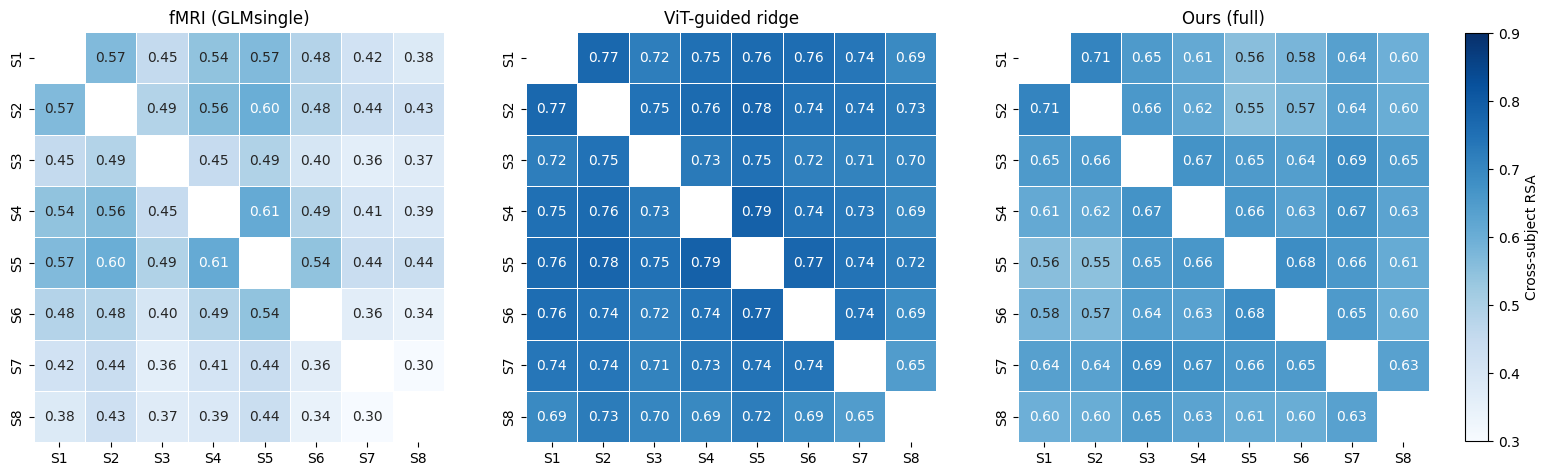

In [54]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

cmap = "Blues"
vmin, vmax = 0.3, 0.9
ticks = [f"S{i+1}" for i in range(8)]
kwargs = dict(
    annot=True,
    fmt=".2f",
    cmap=cmap,
    vmin=vmin,
    vmax=vmax,
    square=True,
    cbar=False,
    linewidths=0.5,
    xticklabels=ticks,
    yticklabels=ticks,
)

# Mask the diagonal
similarities_raw_fmri_masked = np.copy(similarities_raw_fmri)
np.fill_diagonal(similarities_raw_fmri_masked, np.nan)
model_similarities_masked = np.copy(model_similarities)
np.fill_diagonal(model_similarities_masked, np.nan)
encoder_similarities_masked = np.copy(encoder_similarities)
np.fill_diagonal(encoder_similarities_masked, np.nan)

sns.heatmap(similarities_raw_fmri_masked, **kwargs, ax=axes[0])
axes[0].set_title("fMRI (GLMsingle)")
sns.heatmap(model_similarities_masked, **kwargs, ax=axes[1])
axes[1].set_title("ViT-guided ridge")
sns.heatmap(encoder_similarities_masked, **kwargs, ax=axes[2])
axes[2].set_title("Ours (full)")

# Add a cbar to the right of the last heatmap
cbar_ax = fig.add_axes([0.92, 0.155, 0.013, 0.68])
norm = plt.Normalize(vmin=vmin, vmax=vmax)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
fig.colorbar(sm, cax=cbar_ax)
cbar_ax.set_ylabel("Cross-subject RSA", fontsize=10)
fig.savefig("cross_subject_rsa_comparison.pdf", bbox_inches="tight", transparent=True)

In [59]:
print(np.mean(similarities_raw_fmri_masked[~np.isnan(similarities_raw_fmri_masked)]))
print(np.std(similarities_raw_fmri_masked[~np.isnan(similarities_raw_fmri_masked)]))

0.45764888344066484
0.08067797880610539


In [60]:
print(np.mean(model_similarities_masked[~np.isnan(model_similarities_masked)]))
print(np.std(model_similarities_masked[~np.isnan(model_similarities_masked)]))

0.734513759048702
0.030643048875542787


In [61]:
print(np.mean(encoder_similarities_masked[~np.isnan(encoder_similarities_masked)]))
print(np.std(encoder_similarities_masked[~np.isnan(encoder_similarities_masked)]))

0.6329306300197329
0.038621729985905504


In [15]:
template_fmri_pca = "../scripts/steps/subject-{subject:02d}_betas_pca-no-rel.npy"

res = []
pca_embeddings = []
for subject in trange(1, 9):
    X = raw_fmri_avg(subject=subject, template_file=template_fmri_pca)
    pca_embeddings.append(torch.tensor(X).cuda())

for i in trange(len(pca_embeddings)):
    for j in range(len(pca_embeddings)):
        sim = compute_rsa(pca_embeddings[i], pca_embeddings[j])
        acc, cosine, rank = accuracy_cosine_similarity(
            pca_embeddings[i],
            pca_embeddings[j]
            )
        res.append({
            "subject_x": i + 1,
            "subject_y": j + 1,
            "rsa": sim,
            "accuracy": acc,
            "cosine_similarity": cosine,
            "mean_rank": rank,
        })


df = pd.DataFrame(res)
df


  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/8 [00:00<?, ?it/s]

,subject_x,subject_y,rsa,accuracy,cosine_similarity,mean_rank
0,1,1,1.000000,1.000000,1.000000,1.000000
1,1,2,0.510149,0.003883,0.064608,215.996124
2,1,3,0.369639,0.023301,0.218202,119.417480
3,1,4,0.468473,0.001942,0.035184,240.939804
4,1,5,0.495916,0.007767,0.088327,205.607773
...,...,...,...,...,...,...
59,8,4,0.322914,0.005825,0.061540,222.819427
60,8,5,0.399283,0.005825,0.103144,198.355347
61,8,6,0.282378,0.000000,0.026456,249.176697
62,8,7,0.233707,0.005825,0.116205,178.796127


In [19]:
# Aggregate metrics, mean and std, for the off-diagonal elements (cross-subject) for each model
df.query("subject_x != subject_y").agg(["mean", "std"])[["mean_rank", "accuracy", "cosine_similarity", "rsa"]]

,mean_rank,accuracy,cosine_similarity,rsa
mean,189.283847,0.007178,0.108566,0.391002
std,39.481750,0.005479,0.058245,0.082238
